# 01 — Data Preparation

Selects the celebrity subset, builds a stratified per-identity train/val/test split,
and defines the preprocessing/augmentation pipeline. Run `src/select_identities.py`
first (or adjust `IDENTITY_IDS` below manually if your team already chose identities).

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

from dataset import build_splits, CelebASubset, IMAGE_SIZE
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
LOGS_DIR = REPO_ROOT / "logs"


## Load the selected identities

Produced by `python src/select_identities.py` (see that script for the selection rationale).

In [2]:
selected_path = LOGS_DIR / "selected_identities.json"
assert selected_path.exists(), "Run `python src/select_identities.py` first."

selected = json.loads(selected_path.read_text())
IDENTITY_IDS = [row["identity_id"] for row in selected["selected"]]
print("Using identities:", IDENTITY_IDS)
for row in selected["selected"]:
    print(f"  id={row['identity_id']:>6}  n_images={row['num_images']:>3}  attrs={row['dominant_attributes']}")


Using identities: [3, 7, 1212, 8335]
  id=     3  n_images= 25  attrs=['Male', 'Wearing_Hat']
  id=     7  n_images= 24  attrs=['Male', 'Black_Hair']
  id=  1212  n_images= 25  attrs=['Male', 'Black_Hair']
  id=  8335  n_images= 25  attrs=['Male', 'Brown_Hair']


## Build the stratified train/val/test split (15% val, 15% test, per identity)

In [3]:
splits_df = build_splits(IDENTITY_IDS, val_frac=0.15, test_frac=0.15, seed=42)
print(splits_df.groupby(["identity", "split"]).size().unstack(fill_value=0))


split     test  train  val
identity                  
3            4     17    4
7            4     16    4
1212         4     17    4
8335         4     17    4


## Sanity-check a batch of preprocessed/augmented training images

train=67  val=16  test=16  num_classes=4


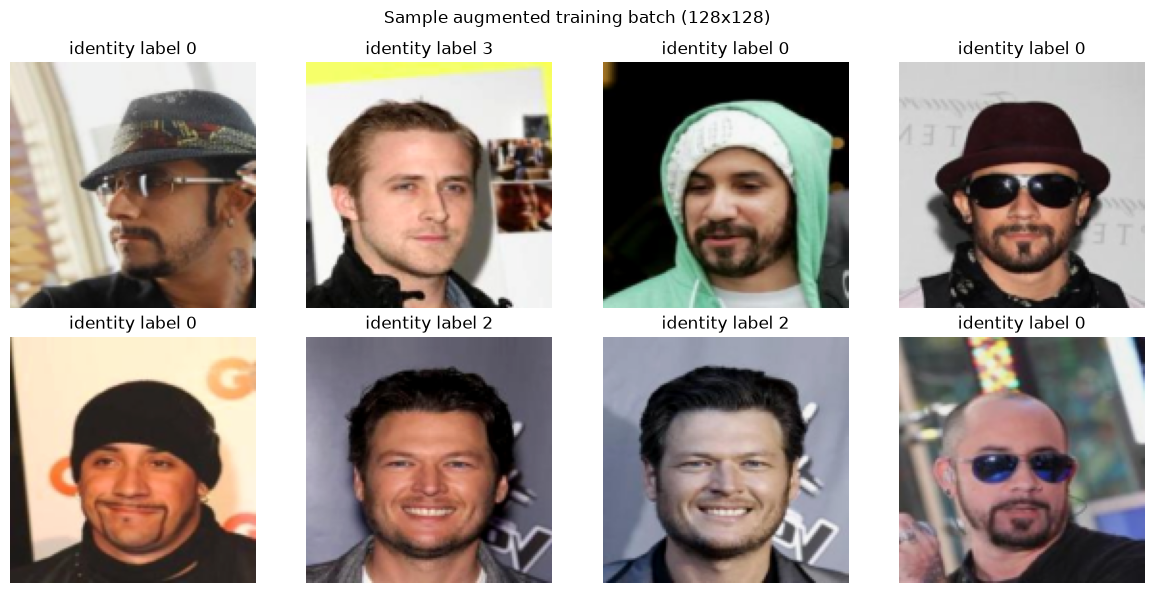

In [4]:
import torch
from torch.utils.data import DataLoader

train_ds = CelebASubset("train", splits_df)
val_ds = CelebASubset("val", splits_df)
test_ds = CelebASubset("test", splits_df)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}  num_classes={train_ds.num_classes}")

loader = DataLoader(train_ds, batch_size=8, shuffle=True)
images, labels = next(iter(loader))

# undo normalization for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for img, label, ax in zip(images, labels, axes.flatten()):
    img = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f"identity label {label.item()}")
    ax.axis("off")
fig.suptitle(f"Sample augmented training batch ({IMAGE_SIZE}x{IMAGE_SIZE})")
fig.tight_layout()
fig.savefig(LOGS_DIR / "sample_batch.png", dpi=150)
plt.show()


## Preprocessing pipeline summary

- **Resize**: all images resized to 128x128 (kept small for CPU-friendly training on
  Explorer's older CPU nodes / limited local hardware).
- **Normalization**: ImageNet mean/std, so both the custom CNN and the pretrained
  ResNet18 see inputs in a consistent, comparable distribution.
- **Augmentation (train split only)**: random horizontal flip (p=0.5), color jitter
  (brightness/contrast/saturation), random rotation (±8°). None applied to val/test so
  evaluation numbers reflect real-world performance.
- **Split**: stratified 70/15/15 per identity, so every identity appears in all three
  splits regardless of class imbalance.

Next: `02_custom_cnn_training.ipynb` and `03_transfer_learning_resnet.ipynb`.